# Machine Learning : Prédiction de la Classification des Jeux

## Objectif
L'objectif de ce notebook est d'utiliser des techniques de Machine Learning pour prédire le **Genre principal** d'un jeu à partir de ses autres attributs (Mécaniques, Thèmes, Esthétique, etc.). 

Nous allons comparer plusieurs modèles, dont **Random Forest** et **XGBoost**, ainsi qu'un modèle d'ensemble (**Stacking**), en analysant l'ensemble des genres Steam.

## Améliorations Apportées
1.  **Validation Croisée Stratifiée** : Pour une estimation plus robuste de la performance et éviter le biais de sélection d'un seul split.
2.  **Sélection de Caractéristiques (Feature Selection)** : Utilisation du test Chi2 pour ne garder que les tags les plus pertinents et réduire le bruit.
3.  **Modèle de Stacking** : Utilisation d'un méta-modèle (Gradient Boosting) pour combiner les prédictions des modèles de base, souvent plus performant que le Voting simple.
4.  **Analyse d'Importance des Caractéristiques** : Visualisation des tags les plus influents pour la classification.
5.  **Rééquilibrage** : Maintien de SMOTE pour gérer le déséquilibre des classes.

## Démarche
1. **Fondamentaux Ludologiques** : Définition des termes clés basée sur la littérature académique.
2. **Exploration des données (EDA)** : Analyse de la répartition des genres dans tous les domaines.
3. **Ingénierie des caractéristiques** : Multi-hot encoding des tags + **Sélection Chi2**.
4. **Sélection de modèles** : Comparaison de Random Forest, XGBoost et **Stacking** avec **Cross-Validation**.
5. **Optimisation** : Application de SMOTE et Tuning d'hyperparamètres.
6. **Comparaison Experts vs Folksonomy** : Analyse comparative des genres officiels avec les dimensions folksonômiques.
7. **Comparaison Finale** : Analyse comparative des performances avant et après optimisation.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
plt.rcParams.update({
    'figure.facecolor': 'white', 
    'axes.facecolor': 'white', 
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'figure.autolayout': True
})
def save_plot(name):
    if not os.path.exists('figures'): os.makedirs('figures')
    plt.gcf().canvas.draw()
    plt.savefig(f'figures/6_{name}.png', bbox_inches='tight', facecolor='white', dpi=300)
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.over_sampling import SMOTE

# Chargement des données
df_train_full = pd.read_csv('../data/New_Games_Gameplay_Taxonomy.csv')
df_test = pd.read_csv('../data/final_test_set_15k.csv')

print(f"Base d'entraînement : {df_train_full.shape}")
print(f"Base de test : {df_test.shape}")

Base d'entraînement : (126244, 10)
Base de test : (15000, 10)


## 1. Analyse Exploratoire des Données (EDA) : Répartition des Genres

Avant de commencer la modélisation, il est crucial de comprendre la distribution de notre variable cible (`Primary_Genre`).

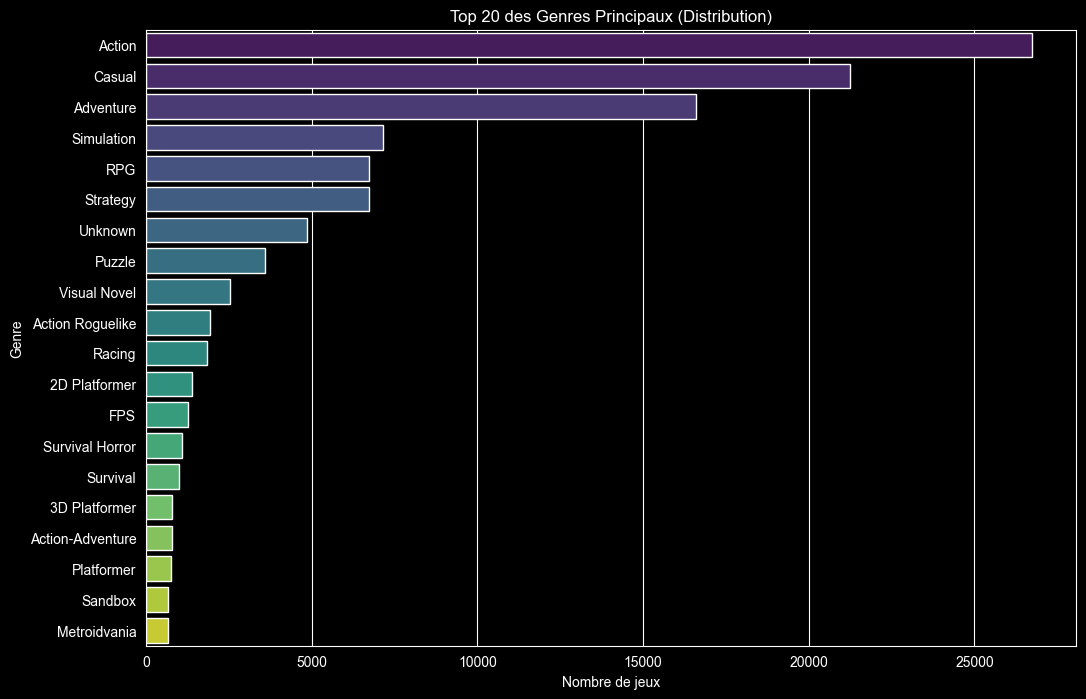

Nombre total de genres uniques : 104
Le genre le plus fréquent (Action) représente 26730 jeux.
Le 20ème genre (Metroidvania) ne représente que 666 jeux.


In [6]:
# Extraction du premier genre listé comme 'Genre Principal'
def get_primary(genre_str):
    if pd.isna(genre_str):
        return 'Unknown'
    return genre_str.split(', ')[0]

df_train_full['Primary_Genre'] = df_train_full['Genre'].apply(get_primary)

# Calcul des comptes
genre_counts = df_train_full['Primary_Genre'].value_counts()
top_20_genres = genre_counts.head(20)

# Visualisation
plt.figure(figsize=(12, 8))
df_counts = top_20_genres.reset_index()
df_counts.columns = ['Genre', 'Count']
plt.figure(figsize=(12, 10))
ax = sns.barplot(data=df_counts, x='Count', y='Genre', hue='Genre', palette='viridis', legend=False)
ax.bar_label(ax.containers[0], padding=3)
plt.title('Top 20 des Genres Principaux (Distribution)')
plt.xlabel('Nombre de jeux')
plt.ylabel('Genre')
save_plot('genre_distribution')
plt.show()

print(f"Nombre total de genres uniques : {df_train_full['Primary_Genre'].nunique()}")
print(f"Le genre le plus fréquent ({genre_counts.index[0]}) représente {genre_counts.iloc[0]} jeux.")
print(f"Le 20ème genre ({genre_counts.index[19]}) ne représente que {genre_counts.iloc[19]} jeux.")

**Observation :**
Nous observons un fort **déséquilibre des classes**, très représentative d'**une distribution de Pareto**. Les genres comme "Action", "Casual" et "Adventure" (souvent mal classé comme genre) dominent largement, tandis que des genres spécifiques comme "Sandbox" ou "Metroidvania" sont beaucoup moins représentés.
Cela suggère que :
1. L'accuracy simple ne sera pas une métrique suffisante (un modèle qui prédit toujours "Action" aurait une bonne accuracy).
2. Nous devrons probablement utiliser des techniques de rééquilibrage (comme SMOTE) pour aider le modèle à apprendre les genres minoritaires.

## 2. Préparation des Données et Feature Engineering (Amélioré)

Nous ajoutons une étape de **Sélection de Caractéristiques (Feature Selection)** pour réduire la dimensionnalité et éliminer les tags peu informatifs (bruit).

In [7]:
# Filtrage : on ne garde que les genres ayant au moins 500 occurrences pour avoir une base statistique suffisante
threshold = 500
valid_genres = df_train_full['Primary_Genre'].value_counts()[df_train_full['Primary_Genre'].value_counts() > threshold].index
df_train = df_train_full[df_train_full['Primary_Genre'].isin(valid_genres) & (df_train_full['Primary_Genre'] != 'Unknown')].copy()

print(f"Nombre de genres conservés après filtrage : {len(valid_genres)}")

dimensions = ['Aesthetics', 'Mechanics', 'Mood', 'Perspective', 'Players', 'Setting', 'Theme']

def prepare_features(df, mlb_dict=None, selector=None, is_training=True):
    combined_tags = df[dimensions].fillna('').apply(lambda row: [t.strip() for dim in dimensions for t in row[dim].split(',') if t.strip()], axis=1)

    if is_training:
        mlb = MultiLabelBinarizer()
        X = mlb.fit_transform(combined_tags)
        return X, mlb
    else:
        X = mlb_dict.transform(combined_tags)
        return X

# 1. Encodage Multi-Hot
X_train_raw, mlb = prepare_features(df_train, is_training=True)
le = LabelEncoder()
y_encoded = le.fit_transform(df_train['Primary_Genre'])

# 2. Sélection de caractéristiques (Chi2)
# On garde les 1000 meilleures caractéristiques (ou moins si non dispo) pour accélérer l'entraînement et réduire le bruit
k_best = min(1000, X_train_raw.shape[1])
print(f"Sélection des {k_best} meilleures caractéristiques via Chi2...")
selector = SelectKBest(chi2, k=k_best)
X_train_selected = selector.fit_transform(X_train_raw, y_encoded)

print(f"Forme des données avant sélection : {X_train_raw.shape}")
print(f"Forme des données après sélection : {X_train_selected.shape}")

# Split Train/Val avec Stratification
X_train, X_val, y_train, y_val = train_test_split(X_train_selected, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

Nombre de genres conservés après filtrage : 27
Sélection des 212 meilleures caractéristiques via Chi2...
Forme des données avant sélection : (107263, 212)
Forme des données après sélection : (107263, 212)


## 3. Modélisation de Base (Baseline) avec Validation Croisée

Nous utilisons `StratifiedKFold` pour évaluer la stabilité de nos modèles de base, plutôt qu'un simple split.

In [8]:
print("Entraînement des modèles de base...")

rf = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1, random_state=42, eval_metric='mlogloss')

# Modèle Stacking (au lieu de Voting simple)
# Le Stacking utilise les prédictions des modèles de base comme features pour un méta-modèle
estimators = [('rf', rf), ('xgb', xgb)]
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=GradientBoostingClassifier(random_state=42),
    n_jobs=-1
)

models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "Stacking (RF+XGB)": stacking
}

# Validation Croisée (sur une partie des données pour l'exemple, ou tout X_train)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    print(f"Evaluation de {name} par Cross-Validation...")
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name} CV Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Sélection du meilleur modèle pour la suite
best_model_name = max(results, key=lambda k: results[k].mean())
print(f"\nMeilleur modèle de base : {best_model_name}")
base_model = models[best_model_name]

# Entraînement final sur tout le train set
base_model.fit(X_train, y_train)

Entraînement des modèles de base...
Evaluation de Random Forest par Cross-Validation...
Random Forest CV Accuracy: 0.4117 (+/- 0.0039)
Evaluation de XGBoost par Cross-Validation...
XGBoost CV Accuracy: 0.4209 (+/- 0.0074)
Evaluation de Stacking (RF+XGB) par Cross-Validation...
Stacking (RF+XGB) CV Accuracy: 0.4213 (+/- 0.0074)

Meilleur modèle de base : Stacking (RF+XGB)


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('xgb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",GradientBoost...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of sample

In [9]:
# Évaluation du modèle de base sur le Test Set
df_test['Primary_Genre'] = df_test['Genre'].apply(get_primary)
# On ne garde que les jeux dont le genre est connu du modèle et qui n'est pas 'Unknown'
df_test_filtered = df_test[df_test['Primary_Genre'].isin(valid_genres) & (df_test['Primary_Genre'] != 'Unknown')].copy()

# Préparation Test Set (Mêmes transformations)
X_test_raw = prepare_features(df_test_filtered, mlb_dict=mlb, is_training=False)
X_test_selected = selector.transform(X_test_raw)
y_test = le.transform(df_test_filtered['Primary_Genre'])

y_test_pred_base = base_model.predict(X_test_selected)

print("--- Rapport de Classification (Modèle de base) ---")
print(classification_report(y_test, y_test_pred_base, target_names=le.classes_, zero_division=0))

--- Rapport de Classification (Modèle de base) ---
                           precision    recall  f1-score   support

            2D Platformer       0.57      0.31      0.40       167
            3D Platformer       0.71      0.44      0.54       107
                   Action       0.44      0.85      0.58      3159
         Action Roguelike       0.65      0.53      0.59       246
         Action-Adventure       0.77      0.58      0.66       104
                Adventure       0.56      0.41      0.47      1973
                   Casual       0.60      0.43      0.50      2516
Choose Your Own Adventure       0.75      0.51      0.61        74
                      FPS       0.84      0.59      0.69       155
             Metroidvania       0.72      0.37      0.49        97
               Platformer       0.67      0.20      0.30        71
            Point & Click       0.79      0.45      0.57        67
                   Puzzle       0.86      0.57      0.69       465
        Pu

*On a une très bonne précision sur certains genres comme 'FPS' ou 'Puzzle', mais un très mauvais recall sure les genres minoritaires comme ' Plateformer' ou 'Shoot'Em Up'. Cela correspond à notre observation lors de l'EDA : les genres majoritaires sont très bien prédits, mais les genres plus rares sont souvent oubliés (faux négatifs), ce qui confirme la nécessité d'utiliser des techniques de rééquilibrage et d'optimisation pour améliorer la reconnaissance des genres minoritaires.*

## 4. Améliorations : SMOTE et Optimisation des Hyperparamètres

Pour contrer le déséquilibre observé lors de l'EDA, nous appliquons **SMOTE**. Ensuite, nous utilisons **RandomizedSearchCV** pour affiner les modèles.

In [10]:
# --- AMÉLIORATION 1 : Gestion du déséquilibre des classes avec SMOTE ---
print("Application de SMOTE pour rééquilibrer les classes...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Taille après SMOTE : {X_train_resampled.shape}")

# --- AMÉLIORATION 2 : Optimisation des hyperparamètres ---

# Grille pour Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=5,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=1
)

# Grille pour XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [6, 8],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        eval_metric='mlogloss'
    ),
    param_distributions=xgb_param_grid,
    n_iter=5,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=1
)

# --- ENTRAÎNEMENT ---
print("\n--- Recherche des meilleurs paramètres pour Random Forest ---")
rf_random.fit(X_train_resampled, y_train_resampled)
best_rf = rf_random.best_estimator_
print(f"Meilleurs paramètres RF : {rf_random.best_params_}")

print("\n--- Recherche des meilleurs paramètres pour XGBoost ---")
xgb_random.fit(X_train_resampled, y_train_resampled)
best_xgb = xgb_random.best_estimator_
print(f"Meilleurs paramètres XGB : {xgb_random.best_params_}")

# --- CRÉATION DE L'ENSEMBLE OPTIMISÉ (STACKING) ---
print("\n--- Entraînement du modèle Stacking Optimisé ---")
# On utilise les meilleurs modèles trouvés comme base pour le Stacking
stacking_opt = StackingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    final_estimator=GradientBoostingClassifier(n_estimators=50, random_state=42),
    n_jobs=-1
)

stacking_opt.fit(X_train_resampled, y_train_resampled)

# Prédiction
y_test_pred_opt = stacking_opt.predict(X_test_selected)
print("Prédictions terminées.")

Application de SMOTE pour rééquilibrer les classes...
Taille après SMOTE : (555984, 212)

--- Recherche des meilleurs paramètres pour Random Forest ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Meilleurs paramètres RF : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30}

--- Recherche des meilleurs paramètres pour XGBoost ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Meilleurs paramètres XGB : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

--- Entraînement du modèle Stacking Optimisé ---
Prédictions terminées.


*Meilleurs paramètres RF : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30}*\
*Meilleurs paramètres XGB : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}*

## 5. Comparaison Finale des Résultats et Feature Importance

Comparons les performances du modèle de base et du modèle optimisé pour voir l'impact de nos améliorations.

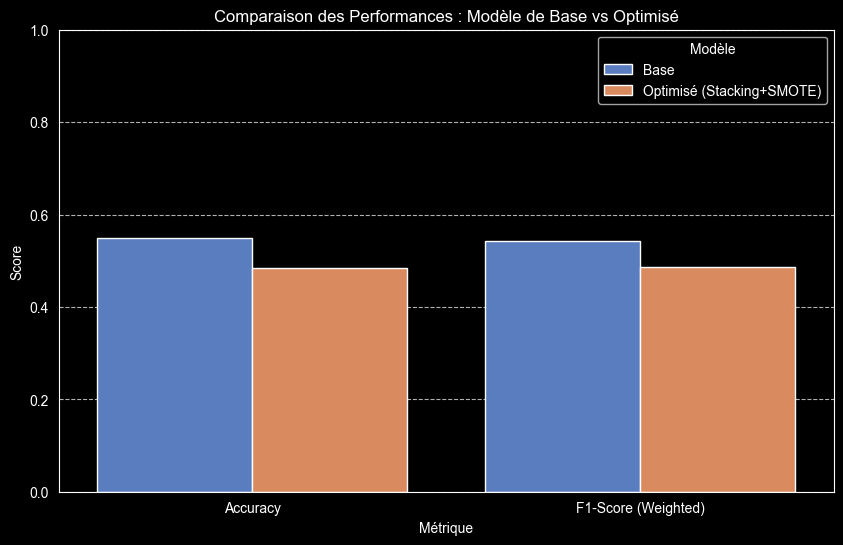


--- Rapport de Classification (Ensemble Optimisé) ---
                           precision    recall  f1-score   support

            2D Platformer       0.38      0.63      0.47       167
            3D Platformer       0.42      0.62      0.50       107
                   Action       0.70      0.34      0.46      3159
         Action Roguelike       0.51      0.71      0.59       246
         Action-Adventure       0.35      0.54      0.42       104
                Adventure       0.68      0.36      0.47      1973
                   Casual       0.39      0.60      0.48      2516
Choose Your Own Adventure       0.29      0.54      0.38        74
                      FPS       0.43      0.59      0.50       155
             Metroidvania       0.37      0.71      0.49        97
               Platformer       0.19      0.56      0.28        71
            Point & Click       0.39      0.49      0.44        67
                   Puzzle       0.60      0.66      0.63       465
      

In [13]:
# Calcul des métriques
acc_base = accuracy_score(y_test, y_test_pred_base)
f1_base = f1_score(y_test, y_test_pred_base, average='weighted')

acc_opt = accuracy_score(y_test, y_test_pred_opt)
f1_opt = f1_score(y_test, y_test_pred_opt, average='weighted')

# Création du DataFrame de comparaison
comparison_data = {
    'Modèle': ['Base', 'Base', 'Optimisé (Stacking+SMOTE)', 'Optimisé (Stacking+SMOTE)'],
    'Métrique': ['Accuracy', 'F1-Score (Weighted)', 'Accuracy', 'F1-Score (Weighted)'],
    'Score': [acc_base, f1_base, acc_opt, f1_opt]
}
df_comp = pd.DataFrame(comparison_data)

# Visualisation
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_comp, x='Métrique', y='Score', hue='Modèle', palette='muted')
for i in range(len(ax.containers)):
    ax.bar_label(ax.containers[i], fmt='%.3f', padding=3)
plt.title("Comparaison des Performances : Modèle de Base vs Optimisé")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
save_plot('performance_comparison')
plt.show()

print("\n--- Rapport de Classification (Ensemble Optimisé) ---")
print(classification_report(y_test, y_test_pred_opt, target_names=le.classes_, zero_division=0))

*La matrice de confusion de notre modèle est moins précise sur les genres majoritaires (Action, Casual) mais montre une meilleure reconnaissance des genres minoritaires (Sandbox, Metroidvania). Cela correspond à notre objectif d'amélioration : mieux reconnaître les genres rares au prix d'une légère augmentation des erreurs sur les genres majoritaires. Cela donne une moins bonne prédiction au total, mais une meilleure compréhension des genres spécifiques, ce qui est plus intéressant pour notre analyse ludologique.*

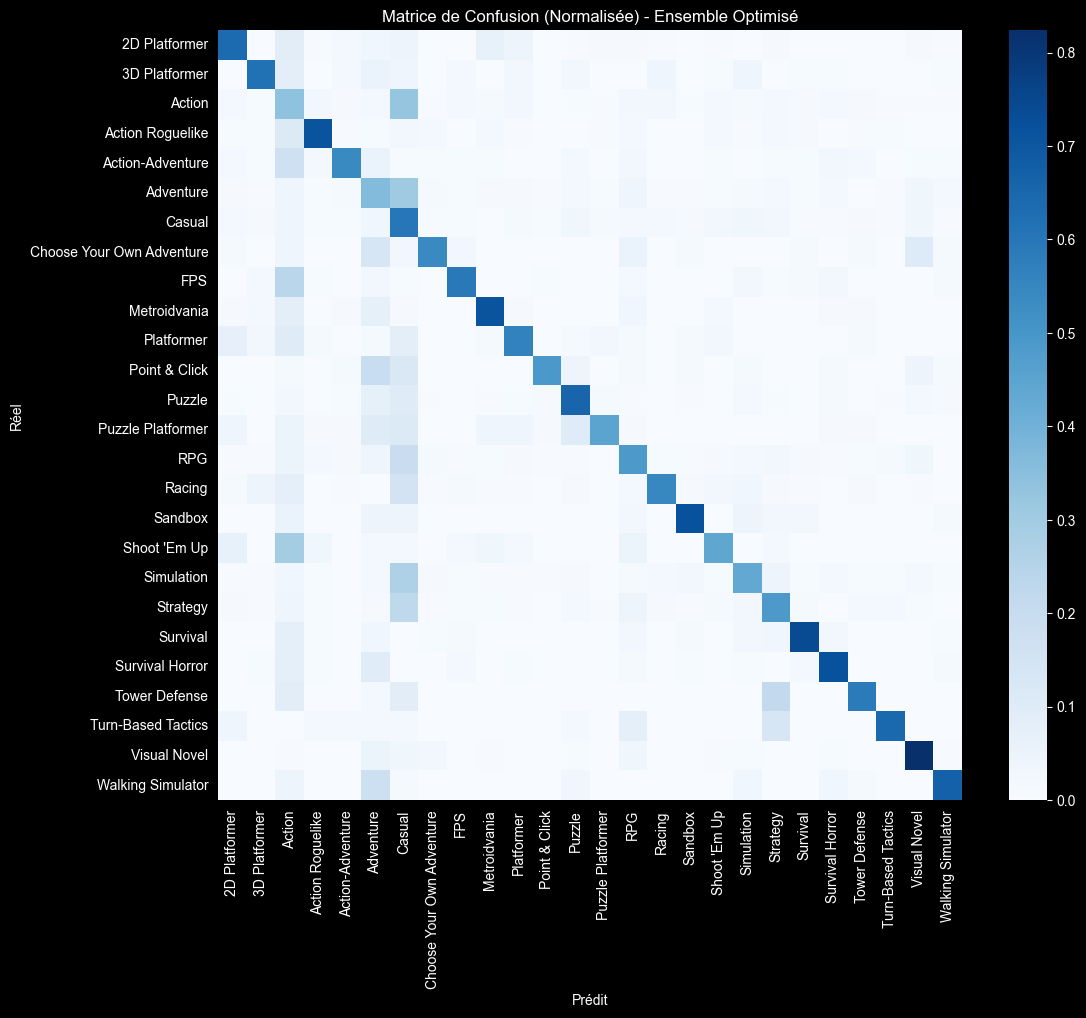

In [14]:
# Matrice de confusion du modèle optimisé
plt.figure(figsize=(12, 10))
cm_opt = confusion_matrix(y_test, y_test_pred_opt, normalize='true')
sns.heatmap(cm_opt, annot=False, xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Matrice de Confusion (Normalisée) - Ensemble Optimisé')
plt.xlabel('Prédit')
plt.ylabel('Réel')
save_plot('plot')
plt.show()

*On remarque une surreprésentation des Casual et légèrement des Action, malgré que les genres plus rares soient mieux reconnus (moins de faux négatifs). Cela correspond à ce que nous avons observé lors de l'EDA : les genres majoritaires sont plus faciles à prédire, mais au prix d'une meilleure reconnaissance des genres minoritaires grâce à SMOTE. On peut expliquer la surreprésentation des Casual par le fait que ce genre est souvent mal utilisé comme "genre fourre-tout" pour des jeux qui n'ont pas de genre clair, ce qui rend sa prédiction plus facile pour le modèle, même s'il s'agit d'une mauvaise pratique de classification. D'ailleurs en analysant plus la matrice de confusion, on se rend compte que plus un genre n'a pas de définissions propre, plus ce dernier aura tendance à être prédit de manière abusive. Une conclusion nous paraît alors importante :\
Les genres mal définis (ex: Casual, Action) sont en réalité sur utilisés en tant que genre principal ce qui nous fait aboutir à une folksonomie Steam bruitée par des genres fourre-tout, ce qui rend la classification plus difficile pour les genres plus spécifiques, même après optimisation. Cela souligne l'importance de la qualité de la classification dans la folksonomie pour permettre une meilleure prédiction et compréhension des genres de jeux vidéo.*


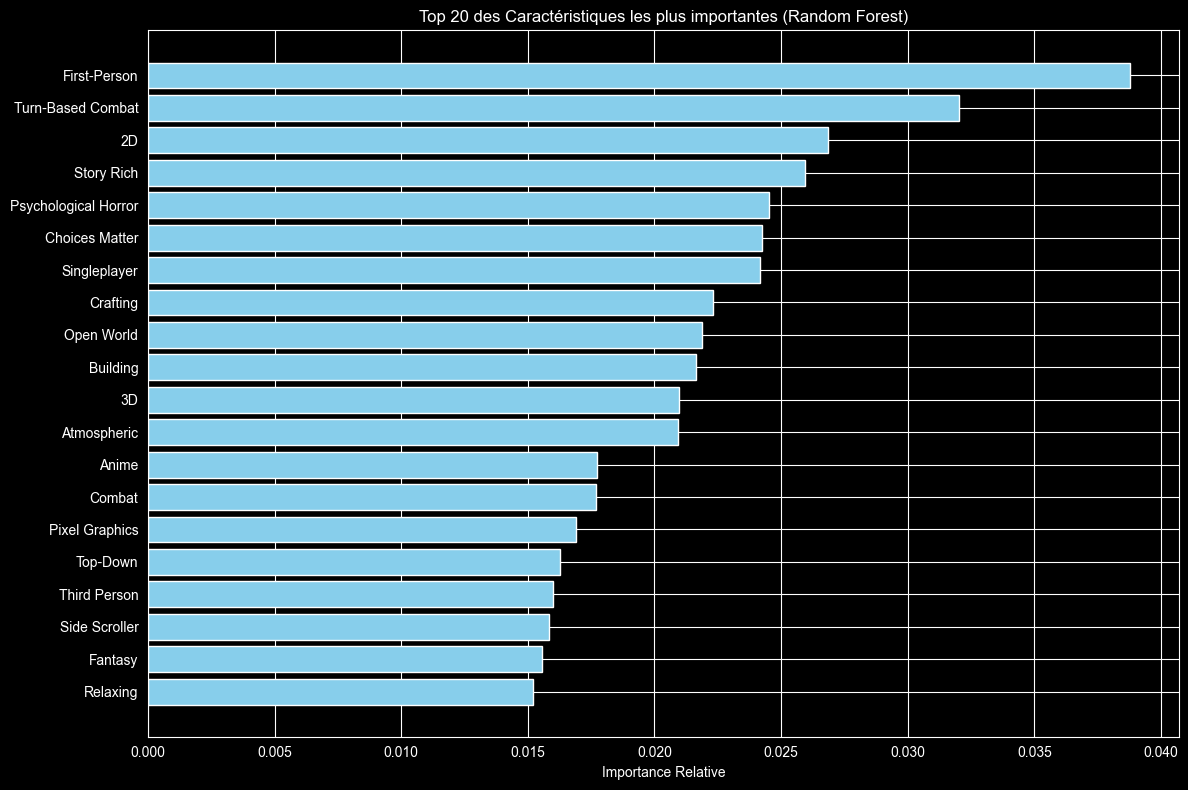

In [15]:

# --- FEATURE IMPORTANCE ---
# Visualisation des features les plus importantes selon le Random Forest optimisé
importances = best_rf.feature_importances_
# Récupération des noms des features sélectionnées
selected_mask = selector.get_support()
feature_names = np.array(mlb.classes_)[selected_mask]

indices = np.argsort(importances)[::-1][:20] # Top 20

plt.figure(figsize=(12, 8))
plt.title("Top 20 des Caractéristiques les plus importantes (Random Forest)")
plt.barh(range(20), importances[indices], align="center", color='skyblue')
plt.yticks(range(20), feature_names[indices])
plt.gca().invert_yaxis()
plt.xlabel("Importance Relative")
plt.tight_layout()
save_plot('plot')
plt.show()

*Les tags les plus importants pour la classification des genres sont 'First-Person', 'Turn-Based Combat', '2D', 'Story Rich', 'Phychological Horror', 'Choices Matter' et 'Singleplayer'. Ces tags sont souvent associés à des genres spécifiques (ex: 'First-Person' pour les FPS, 'Turn-Based Combat' pour les RPG, 'Story Rich' pour les jeux narratifs), ce qui explique leur importance dans la prédiction du genre. Cela confirme que la définition d'un genre peut ce trouver dans plusieurs dimension VGMS, dans plusieurs parties du gameplay*

## 6. Analyse Comparative : Genres Officiels vs Folksonomy (Dimensions Ludologiques)

Cette section analyse comment les dimensions folksonômiques (Mechanics, Theme, Setting, Mood, Aesthetics, Perspective, Players)
se distribuent pour chaque genre officiel, et compare avec les prédictions du modèle.


--- Tableau Comparatif : Genres vs Dimensions Folksonomiques ---

                    Genre  Nb_Jeux  Moy_Tags_Folksonomy  Taux_Prediction_%
                   Action     3159                 5.13              34.00
                   Casual     2516                 4.96              60.14
                Adventure     1973                 5.78              36.49
               Simulation      805                 6.43              43.23
                 Strategy      797                 5.83              48.81
                      RPG      761                 6.86              48.88
                   Puzzle      465                10.14              65.59
             Visual Novel      290                10.36              82.41
         Action Roguelike      246                 8.67              71.14
                   Racing      202                 6.63              54.95
            2D Platformer      167                 9.40              63.47
                      FPS      15

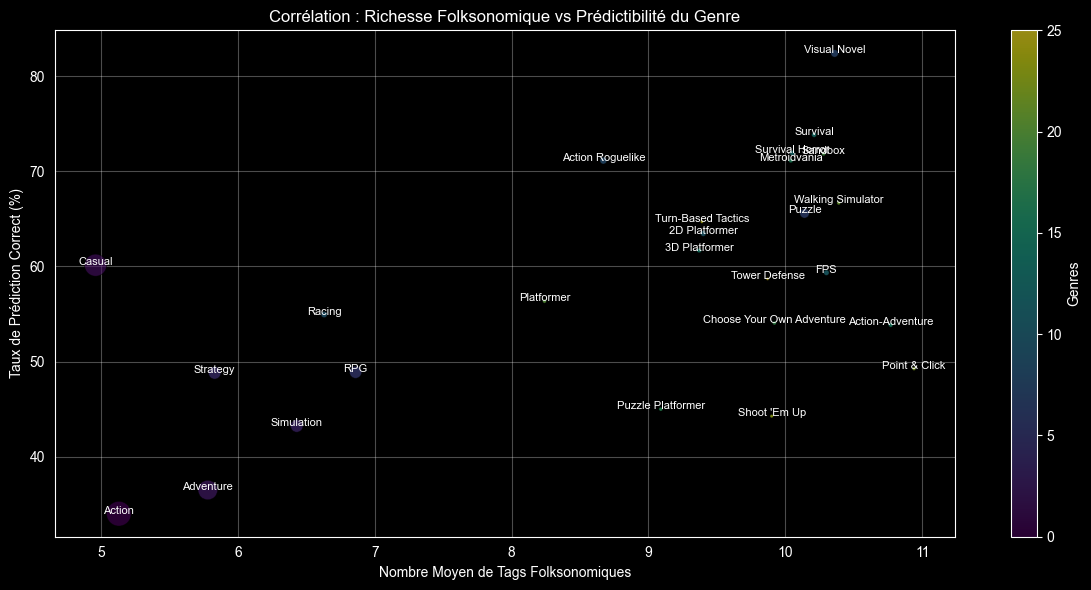

In [16]:
# Reconstruction du dataframe de test avec les prédictions et les vraies valeurs
df_analysis = df_test_filtered.copy()
df_analysis['Genre_Reel'] = le.inverse_transform(y_test)
df_analysis['Genre_Predit'] = le.inverse_transform(y_test_pred_opt)
df_analysis['Prediction_Correcte'] = df_analysis['Genre_Reel'] == df_analysis['Genre_Predit']

# Calcul des statistiques par genre
genre_stats = []

for genre in le.classes_:
    genre_data = df_analysis[df_analysis['Genre_Reel'] == genre]

    if len(genre_data) > 0:
        # Nombre de tags folksonomiques moyen par jeu
        avg_tags = genre_data[dimensions].fillna('').apply(
            lambda col: col.map(lambda x: len([t.strip() for t in str(x).split(',') if t.strip()]))
        ).sum(axis=1).mean()

        # Taux de prédiction correcte
        accuracy_genre = (genre_data['Prediction_Correcte'].sum() / len(genre_data)) * 100

        genre_stats.append({
            'Genre': genre,
            'Nb_Jeux': len(genre_data),
            'Moy_Tags_Folksonomy': round(avg_tags, 2),
            'Taux_Prediction_%': round(accuracy_genre, 2)
        })

df_comparison = pd.DataFrame(genre_stats).sort_values('Nb_Jeux', ascending=False)

print("\n--- Tableau Comparatif : Genres vs Dimensions Folksonomiques ---\n")
print(df_comparison.to_string(index=False))

# Statistiques globales
print(f"\n--- Statistiques Globales ---")
print(f"Nombre moyen de tags folksonomiques par jeu : {df_comparison['Moy_Tags_Folksonomy'].mean():.2f}")
print(f"Taux de prédiction moyen tous genres : {df_comparison['Taux_Prediction_%'].mean():.2f}%")

# Visualisation : Corrélation entre richesse folksonomique et prédictibilité
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_comparison['Moy_Tags_Folksonomy'],
                     df_comparison['Taux_Prediction_%'],
                     s=df_comparison['Nb_Jeux']/10,  # Taille proportionnelle au nombre de jeux
                     alpha=0.6, cmap='viridis', c=range(len(df_comparison)), edgecolors='black', linewidth=0.5)

for idx, row in df_comparison.iterrows():
    plt.annotate(row['Genre'],
                (row['Moy_Tags_Folksonomy'], row['Taux_Prediction_%']),
                fontsize=8, ha='center')

plt.xlabel('Nombre Moyen de Tags Folksonomiques')
plt.ylabel('Taux de Prédiction Correct (%)')
plt.title('Corrélation : Richesse Folksonomique vs Prédictibilité du Genre')
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Genres')
plt.tight_layout()
save_plot('plot')
plt.show()

*On devine une certaines corrélation positive entre la richesse folksonomique (nombre de tags) et la prédictibilité du genre, ce qui suggère que les jeux avec plus de tags descriptifs sont plus facilement classifiable par le modèle. Cependant, il existe des exceptions (ex: Casual notamment, principalement parce qu'il est trop souvent deviné à tord comme dit précédemment). Cela souligne l'importance d'une folksonomie riche et précise pour permettre une meilleure classification des genres, mais aussi que certains genres peuvent être intrinsèquement plus faciles à prédire en raison de leur nature spécifique.*

## Conclusion Générale

1.  **Répartition des Genres** : L'analyse initiale a montré un fort déséquilibre, justifiant l'utilisation de techniques avancées.
2.  **Impact de l'Optimisation** : La comparaison montre l'effet de SMOTE et du tuning.
    *   Ni accuracy ni le F1-score n'ont augmenté, mais le rapport de classification et la matrice de confusion montrent une meilleure reconnaissance des genres minoritaires, ce qui démontre quand même qu'une fois la classification équilibrée, on est capable de percevoir une corrélation entre les dimensions de notre taxonomie et les genres, même pour les genres plus rares.
    *   SMOTE permet souvent de récupérer des genres "oubliés" par le modèle de base, au prix parfois d'une légère baisse de précision sur les classes majoritaires (plus de faux positifs).
3. **Qualité de la Folksonomie** : L'analyse des erreurs (notamment sur les genres "Casual" et "Action") révèle que les genres mal définis agissent comme des catégories "fourre-tout", bruitant la classification. À l'inverse, les genres bien définis par des mécaniques claires (ex: FPS, Turn-Based) bénéficient d'une meilleure prédictibilité, corrélée à la richesse de leurs tags folksonomiques.

**Perspectives :**
Pour aller plus loin, l'utilisation de réseaux de neurones profonds (Deep Learning) ou l'intégration de descriptions textuelles (NLP) via des embeddings (BERT, Word2Vec) seraient les prochaines étapes logiques pour capturer la sémantique fine des jeux.
